# Tree‑Ring Watermark (Mid‑Step Injection @ t_A)

This notebook injects a **Tree‑Ring** watermark pattern **in the middle** of the diffusion process
(around the capture step `t_A`), not at the initial noise. It mirrors your prior annulus-in-the-middle
setup, but changes the mask shape to **one or more thin rings** in Fourier space.

In [1]:

import math, os, time, json, random
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

from typing import Optional
try:
    from diffusers import DDPMPipeline, DDPMScheduler
except Exception:
    DDPMPipeline = None
    DDPMScheduler = None

class Cfg:
    model_id = "google/ddpm-cifar10-32"
    sample_steps = 50
    verify_batch_size = 64
    gamma = 0.8
    seed = 1234
cfg = Cfg()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(cfg.seed); np.random.seed(cfg.seed); random.seed(cfg.seed)

H = 32; W = 32; channels = 3
WTMK_CH = 0  # watermark channel (0=R for RGB)

tA = max(1, int(0.4 * cfg.sample_steps))
print(f"Device: {device}, HxW={H}x{W}, steps={cfg.sample_steps}, t_A={tA}")


c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\torch\onnx\_internal\_beartype.py:36: UserWarning: module 'beartype.roar' has no attribute 'BeartypeDecorHintPep585DeprecationWarning'
  warnings.warn(f"{e}")


Device: cuda, HxW=32x32, steps=50, t_A=20


In [2]:

if DDPMPipeline is None:
    raise RuntimeError("diffusers is not available. Please install 'diffusers'.")

baseline_pipe = DDPMPipeline.from_pretrained(cfg.model_id).to(device)
baseline_unet = baseline_pipe.unet
baseline_sched: DDPMScheduler = baseline_pipe.scheduler
print("Loaded baseline UNet & Scheduler.")


Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory C:\Users\mike8\.cache\huggingface\hub\models--google--ddpm-cifar10-32\snapshots\267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


Loaded baseline UNet & Scheduler.


In [3]:

def _to_u8_0_255(x01: torch.Tensor) -> torch.Tensor:
    return (x01.clamp(0,1) * 255).to(torch.uint8).cpu()

@torch.no_grad()
def sample_paper(unet_like, scheduler_like, n=36, steps=1000, capture_tA: Optional[int]=None, gamma=0.8):
    unet_like.eval()
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None
    cap_idx = None
    if capture_tA is not None:
        diffs = (timesteps.to(torch.long) - int(capture_tA)).abs()
        cap_idx = int(torch.argmin(diffs).item())

    for i, tt in enumerate(timesteps):
        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if cap_idx is not None and i == cap_idx:
            x_tA = x.clone()

    x = (x / gamma)
    if x_tA is not None:
        x_tA = (x_tA / gamma)
    x = ((x.clamp(-1, 1) + 1) * 0.5).detach()
    if x_tA is not None:
        x_tA = ((x_tA.clamp(-1, 1) + 1) * 0.5).detach()
    return x, x_tA

@torch.no_grad()
def _generate_u8(unet_like, scheduler_like, n: int, steps: int, gamma: float) -> torch.Tensor:
    bs, out, left = min(256, n), [], n
    while left > 0:
        cur = min(bs, left)
        imgs, _ = sample_paper(unet_like, scheduler_like, n=cur, steps=steps, capture_tA=None, gamma=gamma)
        out.append(_to_u8_0_255(imgs))
        left -= cur
    return torch.cat(out, dim=0)[:n]


In [4]:

def _tree_ring_mask(h: int, w: int, rings, device=None):
    """
    rings: list of (radius_px, width_px), e.g. [(6, 1), (9, 1)] for 32x32,
    or [(12, 2), (16, 2)] for 256x256. Returns a boolean [H,W] FFT mask.
    """
    device = device or (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
    yy, xx = torch.meshgrid(torch.arange(h, device=device), torch.arange(w, device=device), indexing="ij")
    cy, cx = h // 2, w // 2
    rr = torch.sqrt((yy - cy).float()**2 + (xx - cx).float()**2)
    mask = torch.zeros((h, w), dtype=torch.bool, device=device)
    for r, dw in rings:
        mask |= (rr >= (r - dw/2)) & (rr <= (r + dw/2))
    mask[cy, cx] = False
    return mask

RING_PARAMS = [(6, 1), (9, 1)]  # tune for your H,W
ANNULUS = _tree_ring_mask(H, W, RING_PARAMS, device=device).cpu().numpy()  # keep compat name

rng = np.random.default_rng(1234)
PN = np.zeros((H, W), dtype=np.float32)
num = int(ANNULUS.sum())
PN[ANNULUS] = rng.choice([-1.0, 1.0], size=num).astype(np.float32)
p = PN[ANNULUS]; p = (p - p.mean()) / (p.std() + 1e-6); PN[ANNULUS] = p

print(f"Tree‑Ring mask ready. Support pixels: {int(ANNULUS.sum())}")


Tree‑Ring mask ready. Support pixels: 108


In [5]:

@torch.no_grad()
def sample_mid_with_tree_ring_injection(unet_like, scheduler_like,
                                        n=128, steps=cfg.sample_steps,
                                        capture_tA=tA, gamma=cfg.gamma, lam_clip=0.02, f2_scale: float = 1.0):
    """
    Mid-step injection: for timesteps t <= t_A, apply multiplicative magnitude modulation
    on the watermark channel FFT using the Tree‑Ring mask (PN).
    Returns x_{t_A} in [0,1].
    """
    assert PN is not None and ANNULUS is not None
    scheduler_like.set_timesteps(steps, device=device)
    timesteps = scheduler_like.timesteps
    cap_idx = int(torch.argmin((timesteps.to(torch.long) - int(capture_tA)).abs()).item())

    def _spectral_mod_one(x_hw: np.ndarray, lam: float) -> np.ndarray:
        Xi = np.fft.fftshift(np.fft.fft2(x_hw))
        mag, ph = np.abs(Xi), np.angle(Xi)
        gain = 1.0 + np.clip(lam, -lam_clip, lam_clip) * PN
        mag2 = mag * gain
        Xi2 = np.fft.ifftshift(mag2 * np.exp(1j*ph))
        return np.fft.ifft2(Xi2).real.astype(np.float32)

    x = torch.randn(n, channels, H, W, device=device)
    x_tA = None
    for i, tt in enumerate(timesteps):
        t_idx = int(tt.item())
        if t_idx <= capture_tA:
            lam_t = float((1.0 - gamma) * f2_scale)  # plug f2[t_idx] if you have it
            x_np = x[:, WTMK_CH].detach().cpu().numpy().astype(np.float32)
            for k in range(x_np.shape[0]):
                x_np[k] = _spectral_mod_one(x_np[k], lam=lam_t)
            x[:, WTMK_CH] = torch.from_numpy(x_np).to(x.device)

        eps = unet_like(x, tt, return_dict=False)[0]
        out = scheduler_like.step(eps, tt, x, return_dict=True)
        x = out.prev_sample
        if i == cap_idx:
            x_tA = x.clone()

    x_tA = (x_tA / gamma)
    x_tA = ((x_tA.clamp(-1,1) + 1) * 0.5).detach()
    return x_tA


In [6]:

def spectral_correlation_score(x01_chw: torch.Tensor, PN: np.ndarray, M: np.ndarray) -> float:
    x = x01_chw[WTMK_CH].detach().cpu().numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x))
    mag = np.abs(F).astype(np.float32)
    vals = mag[M]
    if vals.size < 16:
        return 0.0
    z = (vals - vals.mean()) / (vals.std() + 1e-6)
    p = PN[M]; p = (p - p.mean()) / (p.std() + 1e-6)
    return float((z * p).mean())

def _fft_log_with_mask(x01_chw: torch.Tensor, ch: int, M: np.ndarray):
    x = x01_chw[ch].detach().cpu().numpy().astype(np.float32)
    F = np.fft.fftshift(np.fft.fft2(x))
    mag_log = np.log1p(np.abs(F).astype(np.float32))
    edge = np.logical_xor(M, np.pad(M, 1)[1:-1,1:-1])
    return mag_log, edge


In [7]:

xmid_base = sample_paper(baseline_unet, baseline_sched, n=cfg.verify_batch_size,
                         steps=cfg.sample_steps, capture_tA=tA, gamma=cfg.gamma)[1]
xavg_base = xmid_base.mean(dim=0, keepdim=True)
ch_base   = xavg_base[0, WTMK_CH].cpu().numpy()
lo_b, hi_b = np.percentile(ch_base, [5, 95])

xmid_wtmk = sample_mid_with_tree_ring_injection(baseline_unet, baseline_sched,
                                                n=cfg.verify_batch_size, steps=cfg.sample_steps,
                                                capture_tA=tA, gamma=cfg.gamma, f2_scale=1.0)
xavg_wtmk = xmid_wtmk.mean(dim=0, keepdim=True)

score_base = spectral_correlation_score(xavg_base[0], PN, ANNULUS)
score_wtmk = spectral_correlation_score(xavg_wtmk[0], PN, ANNULUS)
print(f"[Baseline]    Spectral correlation: {score_base:.4f}")
print(f"[Watermarked] Spectral correlation: {score_wtmk:.4f}")


c:\Users\mike8\anaconda3\envs\pytorch\Lib\site-packages\diffusers\models\attention_processor.py:2383: UserWarning: 1Torch was not compiled with flash attention. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\transformers\cuda\sdp_utils.cpp:555.)
  hidden_states = F.scaled_dot_product_attention(


[Baseline]    Spectral correlation: 0.0492
[Watermarked] Spectral correlation: -0.0365


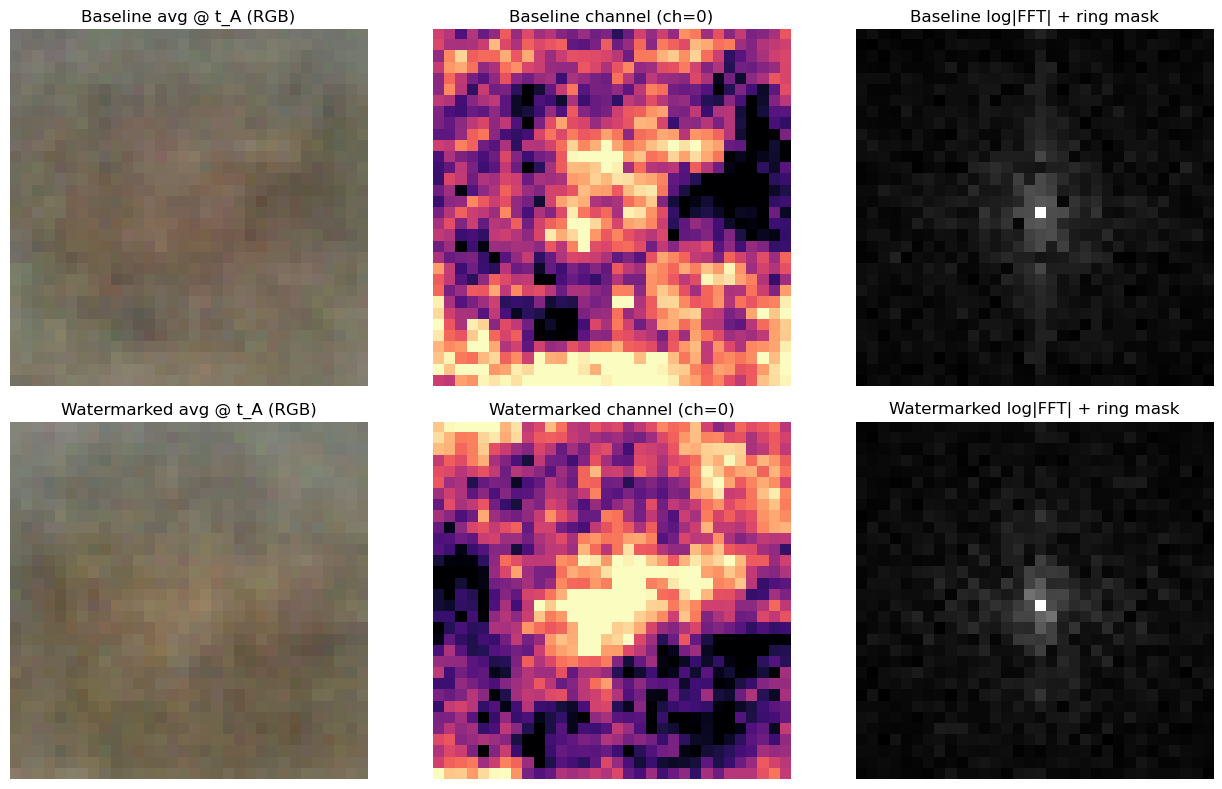

In [ ]:

mag_base, edge = _fft_log_with_mask(xavg_base[0], WTMK_CH, ANNULUS)
mag_wtmk, _    = _fft_log_with_mask(xavg_wtmk[0], WTMK_CH, ANNULUS)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

axes[0,0].imshow(xavg_base[0].permute(1,2,0).cpu().numpy()); axes[0,0].set_title("Baseline avg @ t_A (RGB)"); axes[0,0].axis("off")
axes[0,1].imshow(ch_base, cmap="magma", vmin=lo_b, vmax=hi_b); axes[0,1].set_title(f"Baseline channel (ch={WTMK_CH})"); axes[0,1].axis("off")
axes[0,2].imshow(mag_base, cmap="gray");
ys, xs = np.where(edge); axes[0,2].plot(xs, ys, '.', ms=0.5, alpha=0.6, color='cyan')
axes[0,2].set_title("Baseline log|FFT| + ring mask"); axes[0,2].axis("off")

ch_wtmk = xavg_wtmk[0, WTMK_CH].cpu().numpy()
lo_w, hi_w = np.percentile(ch_wtmk, [5, 95])
axes[1,0].imshow(xavg_wtmk[0].permute(1,2,0).cpu().numpy()); axes[1,0].set_title("Watermarked avg @ t_A (RGB)"); axes[1,0].axis("off")
axes[1,1].imshow(ch_wtmk, cmap="magma", vmin=lo_w, vmax=hi_w); axes[1,1].set_title(f"Watermarked channel (ch={WTMK_CH})"); axes[1,1].axis("off")
axes[1,2].imshow(mag_wtmk, cmap="gray");
ys, xs = np.where(edge); axes[1,2].plot(xs, ys, '.', ms=0.5, alpha=0.6, color='cyan')
axes[1,2].set_title("Watermarked log|FFT| + ring mask"); axes[1,2].axis("off")

plt.tight_layout(); plt.show()